<a href="https://colab.research.google.com/github/eshasrinika/AF-Detection-Single-Lead-ECG/blob/main/AF_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
!pip install scipy
!pip install imbalanced-learn

In [3]:
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

device = torch.device('cuda')
print("Using device:", device)

# ---- Load ECG ----
data = sio.loadmat('ecg_full_dataset.mat')
X = data['X']                          # (1476, 9000)
Y = data['Y'].astype(np.int64).squeeze()

# ---- Load HRV + Morph ----
hrv   = sio.loadmat('derived_HRV_features.mat')
morph = sio.loadmat('morph_features.mat')
X_hrv   = hrv['X_hrv']
X_morph = morph['X_morph']
X_feat  = np.concatenate([X_hrv, X_morph], axis=1)

print("ECG shape:", X.shape)
print("Features shape:", X_feat.shape)
print("Labels:", np.unique(Y, return_counts=True))

Using device: cuda
ECG shape: (1476, 9000)
Features shape: (1476, 19)
Labels: (array([0, 1]), array([738, 738]))


In [4]:
from sklearn.preprocessing import StandardScaler

# Downsample
X = X[:, ::3]                          # 9000 → 3000

# Normalize ECG per recording
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

# Normalize handcrafted features
scaler = StandardScaler()
X_feat = scaler.fit_transform(X_feat)

# Convert to torch
X      = torch.tensor(X,      dtype=torch.float32).unsqueeze(1)  # (1476, 1, 3000)
X_feat = torch.tensor(X_feat, dtype=torch.float32)               # (1476, 19)
Y      = torch.tensor(Y,      dtype=torch.long)

print("ECG tensor:", X.shape)
print("Feature tensor:", X_feat.shape)

ECG tensor: torch.Size([1476, 1, 3000])
Feature tensor: torch.Size([1476, 19])


In [5]:
class FusionAttentionNet(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, 7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # Attention
        self.attn = nn.Linear(128, 1)

        # Fusion classifier: 128 (LSTM) + 19 features
        self.fc = nn.Sequential(
            nn.Linear(128 + 19, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x_ecg, x_feat):
        x = self.cnn(x_ecg)                          # (B, 64, T)
        x = x.permute(0, 2, 1)                       # (B, T, 64)
        x, _ = self.lstm(x)                           # (B, T, 128)
        w = torch.softmax(self.attn(x), dim=1)        # (B, T, 1)
        x = (x * w).sum(dim=1)                        # (B, 128)
        fused = torch.cat([x, x_feat], dim=1)
        return self.fc(fused)

In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Convert to numpy for SMOTE
X_np  = X.squeeze(1).numpy()    # (1476, 3000)
Xf_np = X_feat.numpy()          # (1476, 19)
Y_np  = Y.numpy()

# Stratified split first
X_tr, X_te, Xf_tr, Xf_te, Y_tr, Y_te = train_test_split(
    X_np, Xf_np, Y_np,
    test_size=0.1,
    stratify=Y_np,
    random_state=42
)

# Apply SMOTE to training data only
combined_tr = np.concatenate([X_tr, Xf_tr], axis=1)
sm = SMOTE(random_state=42)
combined_res, Y_res = sm.fit_resample(combined_tr, Y_tr)
X_tr_res  = combined_res[:, :3000]
Xf_tr_res = combined_res[:, 3000:]

print("After SMOTE - Train shape:", X_tr_res.shape)
print("Label counts after SMOTE:", np.unique(Y_res, return_counts=True))

# To tensors
X_train  = torch.tensor(X_tr_res,  dtype=torch.float32).unsqueeze(1)
Xf_train = torch.tensor(Xf_tr_res, dtype=torch.float32)
Y_train  = torch.tensor(Y_res,     dtype=torch.long)

X_test  = torch.tensor(X_te,  dtype=torch.float32).unsqueeze(1)
Xf_test = torch.tensor(Xf_te, dtype=torch.float32)
Y_test  = torch.tensor(Y_te,  dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train, Xf_train, Y_train),
    batch_size=64, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_test, Xf_test, Y_test),
    batch_size=64
)

After SMOTE - Train shape: (1328, 3000)
Label counts after SMOTE: (array([0, 1]), array([664, 664]))


In [13]:
model   = FusionAttentionNet().to(device)
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor([1.15, 1.0]).to(device))
opt     = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
epochs = 35

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb_ecg, xb_feat, yb in train_loader:
        xb_ecg  = xb_ecg.float().to(device)
        xb_feat = xb_feat.float().to(device)
        yb      = yb.to(device)

        # Augmentation
        if torch.rand(1).item() < 0.5:
            xb_ecg = xb_ecg + 0.01 * torch.randn_like(xb_ecg)
        if torch.rand(1).item() < 0.5:
            xb_ecg = xb_ecg * (0.9 + 0.2 * torch.rand(1).item())

        opt.zero_grad()
        loss = loss_fn(model(xb_ecg, xb_feat), yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

Epoch 1: 0.6401
Epoch 2: 0.5277
Epoch 3: 0.4524
Epoch 4: 0.4003
Epoch 5: 0.3703
Epoch 6: 0.3225
Epoch 7: 0.2925
Epoch 8: 0.2727
Epoch 9: 0.2270
Epoch 10: 0.2121
Epoch 11: 0.2077
Epoch 12: 0.1831
Epoch 13: 0.1767
Epoch 14: 0.1627
Epoch 15: 0.1513
Epoch 16: 0.1698
Epoch 17: 0.1802
Epoch 18: 0.1468
Epoch 19: 0.1462
Epoch 20: 0.1437
Epoch 21: 0.1376
Epoch 22: 0.1172
Epoch 23: 0.1078
Epoch 24: 0.1139
Epoch 25: 0.0970
Epoch 26: 0.0851
Epoch 27: 0.0854
Epoch 28: 0.0955
Epoch 29: 0.0981
Epoch 30: 0.0907
Epoch 31: 0.0884
Epoch 32: 0.1019
Epoch 33: 0.0911
Epoch 34: 0.0780
Epoch 35: 0.0676


Threshold tuning:

Threshold 0.40 → Acc=94.58%, AF=95.48%, NSR=93.69%
Threshold 0.45 → Acc=94.81%, AF=95.02%, NSR=94.59%
Threshold 0.50 → Acc=94.81%, AF=94.12%, NSR=95.50%
Threshold 0.55 → Acc=94.81%, AF=93.67%, NSR=95.95%
Threshold 0.60 → Acc=94.13%, AF=92.31%, NSR=95.95%

=========== FINAL METRICS ===========
Accuracy   : 94.81 %
AF Recall  : 95.02 % (Sensitivity)
NSR Recall : 94.59 % (Specificity)
Precision  : 94.59 %
F1 Score   : 94.81 %


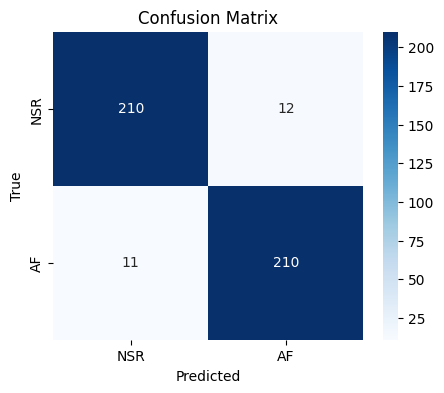

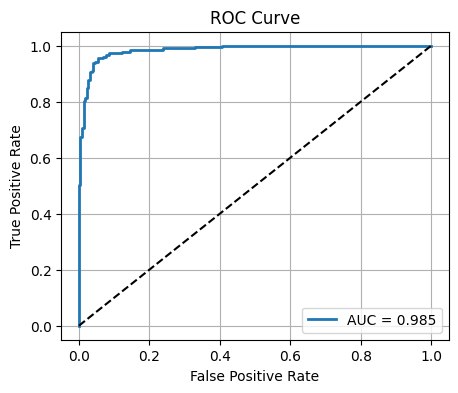

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

model.eval()
all_preds = []
all_true  = []
all_probs = []

with torch.no_grad():
    for xb_ecg, xb_feat, yb in test_loader:
        xb_ecg  = xb_ecg.float().to(device)
        xb_feat = xb_feat.float().to(device)
        out     = model(xb_ecg, xb_feat)
        probs   = torch.softmax(out, dim=1)[:, 1].cpu()
        all_probs.extend(probs.numpy())
        all_true.extend(yb.numpy())

all_probs = np.array(all_probs)
all_true  = np.array(all_true)

# Threshold tuning
print("Threshold tuning:\n")
for t in [0.40, 0.45, 0.50, 0.55, 0.60]:
    preds = (all_probs > t).astype(int)
    cm    = confusion_matrix(all_true, preds)
    TN, FP, FN, TP = cm.ravel()
    acc  = (TP+TN)/cm.sum()
    af   = TP/(TP+FN)
    nsr  = TN/(TN+FP)
    print(f"Threshold {t:.2f} → Acc={acc*100:.2f}%, AF={af*100:.2f}%, NSR={nsr*100:.2f}%")

# Best threshold
threshold  = 0.45
all_preds  = (all_probs > threshold).astype(int)
cm         = confusion_matrix(all_true, all_preds)
TN, FP, FN, TP = cm.ravel()

accuracy   = (TP+TN)/(TP+TN+FP+FN)
af_recall  = TP/(TP+FN)
nsr_recall = TN/(TN+FP)
precision  = TP/(TP+FP)
f1         = 2*(precision*af_recall)/(precision+af_recall)

print("\n=========== FINAL METRICS ===========")
print(f"Accuracy   : {accuracy*100:.2f} %")
print(f"AF Recall  : {af_recall*100:.2f} % (Sensitivity)")
print(f"NSR Recall : {nsr_recall*100:.2f} % (Specificity)")
print(f"Precision  : {precision*100:.2f} %")
print(f"F1 Score   : {f1*100:.2f} %")

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NSR", "AF"],
            yticklabels=["NSR", "AF"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc     = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()